<a href="https://colab.research.google.com/github/Kseniaa31/Data-Science/blob/Password-Strength/Password.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA COLLECTION**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
con = sqlite3.connect("password_data.sqlite")

In [ ]:
data = pd.read_sql_query("SELECT * FROM Users", con)
data.head(4)

,index,password,strength
0,0,zxe870819,1
1,1,xw46454nr23l,1
2,2,soporte13,1
3,3,accounts6000webhost.com,2


# **DATA CLEANING**

In [ ]:
data.drop(["index"],axis=1, inplace=True) #Index is not relevant so we drop
data.head(4)

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
3,accounts6000webhost.com,2


In [ ]:
data.duplicated().sum() #no duplicate
data.isnull().any().sum() #no missing values

np.int64(0)

In [ ]:
data.dtypes

,0
password,object
strength,int64


In [ ]:
data["strength"].unique()

array([1, 2, 0])

# **DATA ANALYSIS**

**SEMANTIC ANALYSIS**

In [ ]:
type(data["password"][0])
#we need to use string functions

str

In [ ]:
data[data["password"].str.isnumeric()].shape

(26, 2)

In [ ]:
data[data["password"].str.isupper()].shape

(1506, 2)

In [ ]:
data[data["password"].str.isalpha()].shape

(50, 2)

In [ ]:
data[data["password"].str.isalnum()].shape

(97203, 2)

In [ ]:
data[data["password"].str.istitle()].shape #title: first character is upper case

(932, 2)

In [ ]:
import string
def find_semantics(row):
  for char in row:
    if char in string.punctuation:
      return 1
    else:
      pass

In [ ]:
data[data["password"].apply(find_semantics)==1]

,password,strength
3,accounts6000webhost.com,2
68,12463773800+,1
98,p.r.c.d.g.,1
145,cita-cita,1
180,karolina.susnina0U,2
...,...,...
99748,maiselis.com,1
99845,hosting4meze!@#,2
99954,semista_bakung15,2
99980,halflife2010!LEB,2


# **FEATURE ENGINEERING**

In [ ]:
data["length"]=data["password"].str.len()

In [ ]:
def freq_lowercase(row):
  return len([char for char in row if char.islower()])/len(row)

def freq_uppercase(row):
  return len([char for char in row if char.isupper()])/len(row)

def freq_numericalcase(row):
  return len([char for char in row if char.isdigit()])/len(row)

def freq_specialcase(row):
  special_chars=[]
  for char in row:
    if not char.isalpha() and not char.isdigit():
      special_chars.append(char)
  return len(special_chars)/len(row)


In [ ]:
data["lowercase_freq"]=np.round(data["password"].apply(freq_lowercase),3)
data["uppercase_freq"]=np.round(data["password"].apply(freq_uppercase),3)
data["digit_freq"]=np.round(data["password"].apply(freq_numericalcase),3)
data["specialChars_freq"]=np.round(data["password"].apply(freq_specialcase),3)
data.head(4)

,password,strength,length,lowercase_freq,uppercase_freq,digit_freq,specialChars_freq
0,zxe870819,1,9,0.333,0.0,0.667,0.000
1,xw46454nr23l,1,12,0.417,0.0,0.583,0.000
2,soporte13,1,9,0.778,0.0,0.222,0.000
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,0.043


**DESCRIPTIVE STATISTICS**

In [19]:
cols=['length','lowercase_freq', 'uppercase_freq','digit_freq','specialChars_freq']
for col in cols:
  print(col)
  print(data[[col, 'strength']].groupby(['strength']).agg(["min","max","mean","median"]))
  print('\n')

length
         length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0


lowercase_freq
         lowercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.708050  0.714
1                   0.0  0.923  0.630067  0.667
2                   0.0  0.917  0.424679  0.400


uppercase_freq
         uppercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.012872  0.000
1                   0.0  0.923  0.007915  0.000
2                   0.0  0.889  0.367633  0.429


digit_freq
         digit_freq                        
                min    max      mean median
strength                                   
0   

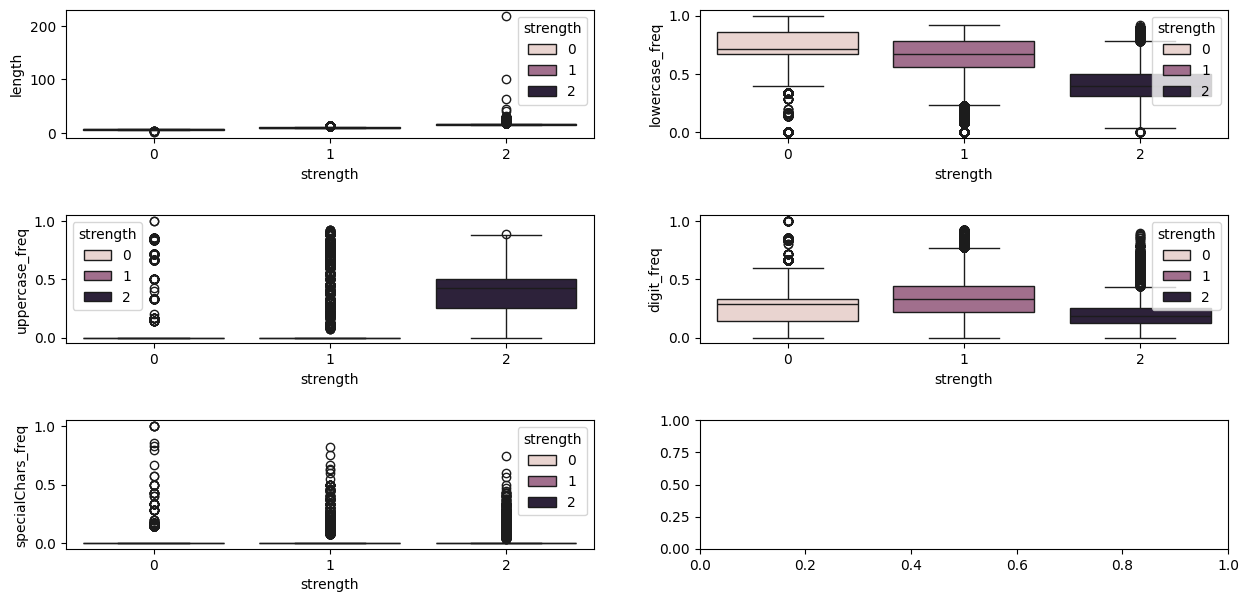

In [24]:
fig, ((ax1,ax2),(ax3,ax4),(ax5,ax6))=plt.subplots(3,2, figsize=(15,7))
sns.boxplot(x="strength",y="length", hue="strength",ax=ax1, data=data)
sns.boxplot(x="strength",y="lowercase_freq", hue="strength",ax=ax2, data=data)
sns.boxplot(x="strength",y="uppercase_freq", hue="strength", ax=ax3, data=data)
sns.boxplot(x="strength",y="digit_freq", hue="strength", ax=ax4, data=data)
sns.boxplot(x="strength",y="specialChars_freq", hue="strength", ax=ax5, data=data)
plt.subplots_adjust(hspace=0.6)